In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
#LR is for binary classification

# Example dataset: Hours studied vs pass/fail (1=pass, 0=fail)
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9]])  # hours studied
y = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])  # labels

#0-fail
#1-pass

In [9]:
# Train logistic regression model
model = LogisticRegression()
model.fit(X, y)

#fit - build the relationship between X/features and Y / label
#model will estimate a function - 1/1+e^-(B0+B1.x)
#B0 = intercept / bias
#B1=coefficient (weight for hours studied)

LogisticRegression()

In [10]:
print("Coefficient...", model.coef_)
print("intercept...", model.intercept_)

Coefficient... [[1.17809125]]
intercept... [-5.29550199]


In [11]:
# Generate predictions (probabilities)
x_test = np.linspace(0, 10, 100).reshape(-1, 1)
#[[0.0],
# [[0.1],
#...
#[10.0]]
y_prob = model.predict_proba(x_test)[:, 1]

In [12]:
# Find decision boundary (x where probability ~ 0.5)
decision_boundary = -model.intercept_[0] / model.coef_[0][0]
print(decision_boundary)
#B0+B1X=0
#X=-B0/B1

#decision_boundary gives critical no.of study hours at which model predicts exactly 50% chance of passing
#   if hours < bounday --> predict fail (0)
#   if hours > bounday > predict pass (1)

4.49498458092253


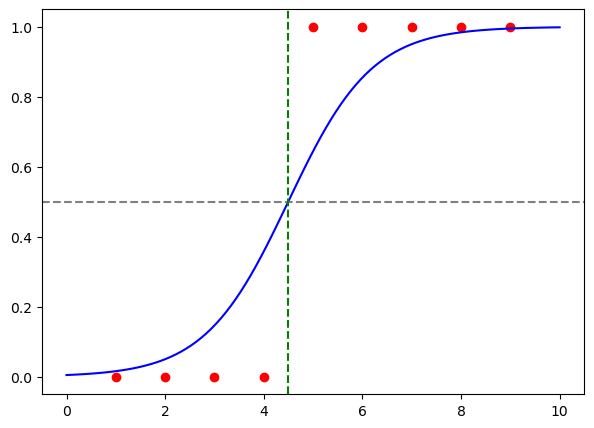

In [13]:
# Plot the sigmoid curve
plt.figure(figsize=(7,5))
plt.scatter(X, y, color='red', label="Actual data (0=Fail, 1=Pass)")
plt.plot(x_test, y_prob, color='blue', label="Sigmoid Prediction Curve")
plt.axhline(0.5, color="gray", linestyle="--", label="Decision Threshold (0.5)")
plt.axvline(decision_boundary, color="green", linestyle="--", label=f"Decision Boundary ≈ {decision_boundary:.2f} hrs")

#logistic regression always expresses outcomes in terms of probabilities

In [14]:
# Print probabilities and classifications for specific hours
sample_hours = np.array([[2], [5], [8]])
pred_probs = model.predict_proba(sample_hours)[:, 1]
pred_classes = model.predict(sample_hours)

for h, p, c in zip(sample_hours.flatten(), pred_probs, pred_classes):
    result = "Pass" if c == 1 else "Fail"
    print(f"Hours studied = {h} --> Probability of passing = {p:.2f} --> Prediction = {result}")


Hours studied = 2 --> Probability of passing = 0.05 --> Prediction = Fail
Hours studied = 5 --> Probability of passing = 0.64 --> Prediction = Pass
Hours studied = 8 --> Probability of passing = 0.98 --> Prediction = Pass
